# Credit Reporting Complaint Topic Modeling

## Overview

This notebook applies unsupervised learning to Consumer Financial Protection Bureau complaint narratives to identify recurring themes within credit-reporting complaints.

The CFPB already classifies complaints using fields such as Product, Issue, and Sub-issue. This analysis explores whether narrative text can reveal additional patterns that complement those existing categories.


## Analysis Workflow

**CFPB complaints → Stratified sample → Narrative screening → Credit-reporting subset → Sentence embeddings → UMAP → HDBSCAN → Topic interpretation → Sensitivity analysis**

## Table of Contents

1. [Setup and Data Loading](#1-setup-and-data-loading)
2. [Select a Representative Sample](#2-select-a-representative-sample)
3. [Screen Repetitive and Low-Information Narratives](#3-screen-repetitive-and-low-information-narratives)
4. [Select Credit-Reporting Complaints](#4-select-credit-reporting-complaints)
5. [Convert Narratives into Sentence Embeddings](#5-convert-narratives-into-sentence-embeddings)
6. [Reduce Embedding Dimensions with UMAP](#6-reduce-embedding-dimensions-with-umap)
7. [Generate Complaint Topics with HDBSCAN](#7-generate-complaint-topics-with-hdbscan)
8. [Model Selection and Parameter Sensitivity](#8-model-selection-and-parameter-sensitivity)
9. [Topic Interpretation](#9-topic-interpretation)
10. [Topic Similarity and Broader Themes](#10-topic-similarity-and-broader-themes)
11. [Outlier Analysis](#11-outlier-analysis)
12. [Additional Sensitivity Checks](#12-additional-sensitivity-checks)
13. [Limitations](#13-conslusion)
14. [Conclusion](#14-conclusion)

## 1. Setup and Data Loading

This analysis begins with the prepared df_filtered.csv dataset. This file contains complaint narratives and standardized product labels that were created during Po-Wen Lai's NLP work.

Only three columns are required for this analysis:

- `Complaint ID`
- `Product_Standardized`
- `cleaned_narrative`

In [1]:
from pathlib import Path
from itertools import combinations
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import (
    ENGLISH_STOP_WORDS,
    TfidfVectorizer,
)
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from umap import UMAP

import warnings

warnings.filterwarnings(
    "ignore",
    message="n_jobs value 1 overridden to 1 by setting random_state"
)

In [2]:
RANDOM_SEED = 42

DATA_PATH = Path("data/df_filtered.csv")
OUTPUT_DIR = Path("clean_rebuild_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find {DATA_PATH.resolve()}")

df_filtered = pd.read_csv(DATA_PATH)

required_columns = {
    "Complaint ID",
    "Product_Standardized",
    "cleaned_narrative",
}

missing_columns = required_columns - set(df_filtered.columns)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

data_summary = pd.Series({
    "Complaints": len(df_filtered),
    "Columns": len(df_filtered.columns),
    "Missing cleaned narratives": (
        df_filtered["cleaned_narrative"].isna().sum()
    ),
    "Duplicate complaint IDs": (
        df_filtered["Complaint ID"].duplicated().sum()
    ),
    "Product categories": (
        df_filtered["Product_Standardized"].nunique()
    ),
})

display(data_summary.to_frame("value"))

df_filtered[
    [
        "Complaint ID",
        "Product_Standardized",
        "Issue",
        "Sub-issue",
        "cleaned_narrative",
    ]
].head(3)

,value
Complaints,1055842
Columns,21
Missing cleaned narratives,0
Duplicate complaint IDs,0
Product categories,10


,Complaint ID,Product_Standardized,Issue,Sub-issue,cleaned_narrative
0,12856469,Credit reporting or other personal consumer reports,Incorrect information on your report,Account information incorrect,"To Whom It May Concern, I am filing a formal complaint against Mohela, [MASKED_TEXT], [MASKED_TEXT], and [MASKED_TEXT] for continued reporting and collection of student loan debt that is now legal..."
1,12989708,Student loan,Struggling to repay your loan,"Problem with forgiveness, cancellation, or discharge","Struggling with a [MASKED_TEXT] has significantly impacted my financial stability, making it impossible for me to meet my student loan obligations. The challenges I face daily limit my ability to ..."
2,13062648,Student loan,Dealing with your lender or servicer,Trouble with how payments are being handled,"I have taken out parent loans on behalf of my daughter, who is a full-time student. I got a notification in [MASKED_TEXT]/[MASKED_TEXT]/year> that the loans were coming due and repayment starts in..."


## 2. Select a Representative Sample

The prepared dataset contains more than one million complaint narratives. Generating sentence embeddings for the full dataset would require substantial computational resources, so the analysis uses a stratified sample of 10,000 complaints.

The sample is stratified by standardized product category. This preserves approximately the same product distribution as the full dataset while keeping the analysis computationally manageable.

In [4]:
sample_10k, _ = train_test_split(
    df_filtered,
    train_size=10_000,
    stratify=df_filtered["Product_Standardized"],
    random_state=RANDOM_SEED,
)

sample_10k = sample_10k.reset_index(drop=True)

assert len(sample_10k) == 10_000
assert sample_10k["Complaint ID"].is_unique
assert sample_10k["cleaned_narrative"].notna().all()

print(f"Complaints selected: {len(sample_10k):,}")
print(
    "Product categories represented:",
    sample_10k["Product_Standardized"].nunique(),
)

Complaints selected: 10,000
Product categories represented: 10


In [5]:
full_product_share = (
    df_filtered["Product_Standardized"]
    .value_counts(normalize=True)
    .rename("Full dataset")
)

sample_product_share = (
    sample_10k["Product_Standardized"]
    .value_counts(normalize=True)
    .rename("10K sample")
)

product_comparison = pd.concat(
    [full_product_share, sample_product_share],
    axis=1,
).fillna(0)

product_comparison["Difference (percentage points)"] = (
    product_comparison["10K sample"]
    - product_comparison["Full dataset"]
) * 100

display(
    product_comparison
    .sort_values("Full dataset", ascending=False)
    .round(4)
)

,Full dataset,10K sample,Difference (percentage points)
Product_Standardized,,,
Credit reporting or other personal consumer reports,0.7422,0.7422,0.0019
Debt collection,0.0829,0.0829,0.0011
"Money transfer, virtual currency, or money service",0.0572,0.0572,0.0022
Checking or savings account,0.0428,0.0428,0.0016
Credit Card/Prepaid,0.0372,0.0372,-0.0043
Mortgage,0.0111,0.0111,-0.0028
Vehicle loan or lease,0.0094,0.0094,-0.0020
Student loan,0.0088,0.0088,-0.0047
"Payday loan, title loan, personal loan, or advance loan",0.0064,0.0065,0.0052


The product shares in the sample closely match those in the full dataset, indicating that stratification preserved the overall product distribution.

Larger samples were explored during model development. Although they increased the amount of data, they did not produce a clearer or more interpretable topic structure, while substantially increasing computational cost.

## 3. Screen Repetitive and Low-Information Narratives

Complaint datasets often contain repeated form letters, very short submissions, and heavily masked narratives. These records can dominate the semantic representation even though they add limited information about distinct consumer experiences.

A complaint is flagged when it meets at least one of the following conditions:

- its cleaned narrative is an exact duplicate;
- it contains fewer than 50 words;
- its first 10 words occur in more than 10 complaints;
- masking tokens make up more than 30% of its words.

Complaints meeting any of these rules are removed before topic modeling.

In [6]:
MASK_PATTERN = (
    r"\[MASKED_TEXT\]"
    r"|\[MASKED_DATE\]"
    r"|\[MASKED_AMOUNT\]"
    r"|\[REDACTED\]"
)

sample_analyzed = sample_10k.copy()

sample_analyzed["clustering_word_count"] = (
    sample_analyzed["cleaned_narrative"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

sample_analyzed["opening_phrase"] = (
    sample_analyzed["cleaned_narrative"]
    .fillna("")
    .astype(str)
    .apply(lambda text: " ".join(text.split()[:10]).lower())
)

opening_counts = (
    sample_analyzed["opening_phrase"].value_counts()
)

sample_analyzed["masked_count"] = (
    sample_analyzed["cleaned_narrative"]
    .fillna("")
    .astype(str)
    .str.count(MASK_PATTERN)
)

sample_analyzed["masked_ratio"] = np.where(
    sample_analyzed["clustering_word_count"] > 0,
    (
        sample_analyzed["masked_count"]
        / sample_analyzed["clustering_word_count"]
    ),
    0.0,
)

sample_analyzed["is_exact_duplicate"] = (
    sample_analyzed["cleaned_narrative"]
    .duplicated(keep=False)
)

sample_analyzed["is_very_short"] = (
    sample_analyzed["clustering_word_count"] < 50
)

sample_analyzed["is_common_opening"] = (
    sample_analyzed["opening_phrase"]
    .map(opening_counts)
    .gt(10)
)

sample_analyzed["is_highly_redacted"] = (
    sample_analyzed["masked_ratio"] > 0.30
)

sample_analyzed["is_potential_template"] = (
    sample_analyzed["is_exact_duplicate"]
    | sample_analyzed["is_very_short"]
    | sample_analyzed["is_common_opening"]
    | sample_analyzed["is_highly_redacted"]
)

df_substantive = (
    sample_analyzed.loc[
        ~sample_analyzed["is_potential_template"]
    ]
    .sort_values("Complaint ID")
    .reset_index(drop=True)
    .copy()
)

In [7]:
template_summary = pd.DataFrame({
    "Screening rule": [
        "Exact duplicate",
        "Fewer than 50 words",
        "Common opening phrase",
        "More than 30% masked",
        "Flagged by at least one rule",
        "Complaints retained",
    ],
    "Complaints": [
        int(sample_analyzed["is_exact_duplicate"].sum()),
        int(sample_analyzed["is_very_short"].sum()),
        int(sample_analyzed["is_common_opening"].sum()),
        int(sample_analyzed["is_highly_redacted"].sum()),
        int(sample_analyzed["is_potential_template"].sum()),
        len(df_substantive),
    ],
})

display(template_summary)

,Screening rule,Complaints
0,Exact duplicate,3408
1,Fewer than 50 words,1244
2,Common opening phrase,3673
3,More than 30% masked,620
4,Flagged by at least one rule,5273
5,Complaints retained,4727


The screening-rule counts overlap because a single complaint can meet more than one condition. For example, a narrative may be both very short and heavily masked. Therefore, the individual rule counts should not be added together.

The screening process retained 4,727 complaints containing more substantive narrative content. These complaints form the text pool used for the detailed credit-reporting analysis.

### Semantic Similarity Review

A separate sensitivity analysis evaluated whether highly similar narratives should also be removed. Manual review showed that complaints with nearly identical legal wording could still describe different companies, accounts, or consumer circumstances.

For this reason, semantic similarity was not used as an automatic exclusion rule. All 4,727 complaints that passed the screening rules above were retained.

## 4. Select Credit-Reporting Complaints

Credit reporting is the largest product category in the sample. It also contains a wide range of issues involving identity theft, inaccurate account information, payment history, inquiries, collections, and dispute investigations.

The remaining analysis therefore focuses on complaints categorized as:

**Credit reporting or other personal consumer reports**

In [8]:
CREDIT_PRODUCT = (
    "Credit reporting or other personal consumer reports"
)

df_credit = (
    df_substantive.loc[
        df_substantive["Product_Standardized"]
        == CREDIT_PRODUCT
    ]
    .sort_values("Complaint ID")
    .reset_index(drop=True)
    .copy()
)

assert df_credit["Complaint ID"].is_unique
assert df_credit["cleaned_narrative"].notna().all()

credit_summary = pd.Series({
    "Original prepared dataset": len(df_filtered),
    "Stratified sample": len(sample_10k),
    "Complaints after narrative screening": len(df_substantive),
    "Credit-reporting complaints selected": len(df_credit),
    "Share of screened complaints": (
        len(df_credit) / len(df_substantive) * 100
    ),
})

display(credit_summary.to_frame("value").round(1))

,value
Original prepared dataset,1055842.0
Stratified sample,10000.0
Complaints after narrative screening,4727.0
Credit-reporting complaints selected,2902.0
Share of screened complaints,61.4


In [9]:
credit_issue_summary = (
    df_credit["Issue"]
    .value_counts()
    .rename_axis("Issue")
    .reset_index(name="Complaints")
)

credit_issue_summary["Share (%)"] = (
    credit_issue_summary["Complaints"]
    / len(df_credit)
    * 100
)

display(credit_issue_summary.round(1))

,Issue,Complaints,Share (%)
0,Incorrect information on your report,1462,50.4
1,Problem with a company's investigation into an existing problem,689,23.7
2,Improper use of your report,688,23.7
3,Unable to get your credit report or credit score,21,0.7
4,Problem with fraud alerts or security freezes,21,0.7
5,Credit monitoring or identity theft protection services,18,0.6
6,Problem with a company's investigation into an existing issue,2,0.1
7,Identity theft protection or other monitoring services,1,0.0


## Data Preparation Summary

The analysis began with 1,055,842 prepared complaints and selected a stratified sample of 10,000.

Screening for exact duplicates, very short narratives, repeated opening phrases, and heavily masked text retained 4,727 complaints. The final modeling dataset contains 2,902 credit-reporting complaints.

No semantic near-duplicate rule was applied because highly similar wording did not always indicate the same underlying consumer experience.

The next section converts these 2,902 narratives into sentence embeddings for semantic clustering.

## 5. Convert Narratives into Sentence Embeddings

Clustering algorithms require numerical inputs, while complaint narratives are text. The `all-mpnet-base-v2` sentence-transformer model is used to convert each complaint into a 768-dimensional embedding.

These embeddings represent semantic meaning, allowing complaints with similar content to appear closer together even when they use different wording.

In [10]:
EMBEDDING_MODEL_NAME = "all-mpnet-base-v2"
EMBEDDINGS_PATH = OUTPUT_DIR / "credit_reporting_embeddings.npy"

embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

credit_texts = (
    df_credit["cleaned_narrative"]
    .fillna("")
    .astype(str)
    .tolist()
)

embeddings = embedding_model.encode(
    credit_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=False,
)

assert embeddings.shape == (len(df_credit), 768)

np.save(EMBEDDINGS_PATH, embeddings)

print(f"Complaints embedded: {len(df_credit):,}")
print(f"Embedding dimensions: {embeddings.shape[1]}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/91 [00:00<?, ?it/s]

Complaints embedded: 2,902
Embedding dimensions: 768


### Embedding Summary

Each complaint narrative was converted into a 768-dimensional sentence embedding using the `all-mpnet-base-v2` Sentence Transformer model.

Unlike TF-IDF features, sentence embeddings capture semantic meaning rather than exact word overlap. This allows complaints describing similar problems with different wording to be positioned close together in the embedding space.

These embeddings serve as the numerical representation for all subsequent dimensionality reduction and clustering analyses.

## 6. Reduce Embedding Dimensions with UMAP

The sentence embeddings contain 768 dimensions. UMAP is used to reduce them to five dimensions before clustering.

This reduced representation preserves local semantic relationships while making density-based clustering more practical. A separate two-dimensional UMAP projection is used later for visualization only.

In [11]:
FINAL_UMAP_NEIGHBORS = 10
FINAL_UMAP_SEED = 22

umap_model = UMAP(
    n_neighbors=FINAL_UMAP_NEIGHBORS,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=FINAL_UMAP_SEED,
)

umap_embeddings = umap_model.fit_transform(embeddings)

assert umap_embeddings.shape == (len(df_credit), 5)

print(f"Reduced embedding shape: {umap_embeddings.shape}")

Reduced embedding shape: (2902, 5)


### UMAP Summary

The original sentence embeddings contain 768 dimensions, which are unsuitable for direct clustering because of their high dimensionality.

UMAP reduced each complaint to a five-dimensional representation while preserving local semantic relationships between complaints. This lower-dimensional representation was used as the input to HDBSCAN.

A separate two-dimensional UMAP projection was generated later only for visualization and was not used during clustering.

## 7. Cluster Complaints with HDBSCAN

HDBSCAN identifies dense groups of semantically similar complaints without requiring the number of topics to be specified in advance.

The selected configuration uses a minimum cluster size of 50 and `min_samples=20`. Complaints that do not belong to a sufficiently dense region are labeled as outliers rather than being forced into a topic.

In [12]:
FINAL_MIN_CLUSTER_SIZE = 50
FINAL_MIN_SAMPLES = 20

hdbscan_model = HDBSCAN(
    min_cluster_size=FINAL_MIN_CLUSTER_SIZE,
    min_samples=FINAL_MIN_SAMPLES,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)

final_labels = hdbscan_model.fit_predict(umap_embeddings)

n_topics = len(set(final_labels) - {-1})
n_assigned = int((final_labels != -1).sum())
n_outliers = int((final_labels == -1).sum())

model_summary = pd.Series({
    "Topics": n_topics,
    "Assigned complaints": n_assigned,
    "Outliers": n_outliers,
    "Outlier rate (%)": n_outliers / len(final_labels) * 100,
})

display(model_summary.to_frame("value").round(1))

,value
Topics,13.0
Assigned complaints,1838.0
Outliers,1064.0
Outlier rate (%),36.7


### Initial Clustering Results

Two HDBSCAN configurations were evaluated using the same UMAP representation.

The configuration with `min_samples = 10` assigned more complaints to clusters, whereas `min_samples = 20` produced a more conservative solution with additional outliers. Because HDBSCAN intentionally labels uncertain observations as noise, the more conservative configuration was retained for further evaluation.

The following sections examine whether this choice remains appropriate under different UMAP settings, random seeds, and HDBSCAN parameters.

## 8. Model Selection and Parameter Sensitivity

Several UMAP and HDBSCAN configurations were evaluated before selecting the final model. The analysis considered topic balance, outlier rate, interpretability, and stability across random seeds.

### 8.1 Visual Inspection of the Embedding Space

A two-dimensional UMAP projection was created to visually inspect the semantic structure of the complaint embeddings.

This projection is used only for visualization. The clustering model uses a separate five-dimensional UMAP representation.

In [13]:
visual_umap = UMAP(
    n_neighbors=FINAL_UMAP_NEIGHBORS,
    n_components=2,
    min_dist=0.0,
    metric="cosine",
    random_state=FINAL_UMAP_SEED,
).fit_transform(embeddings)

assert visual_umap.shape == (len(df_credit), 2)

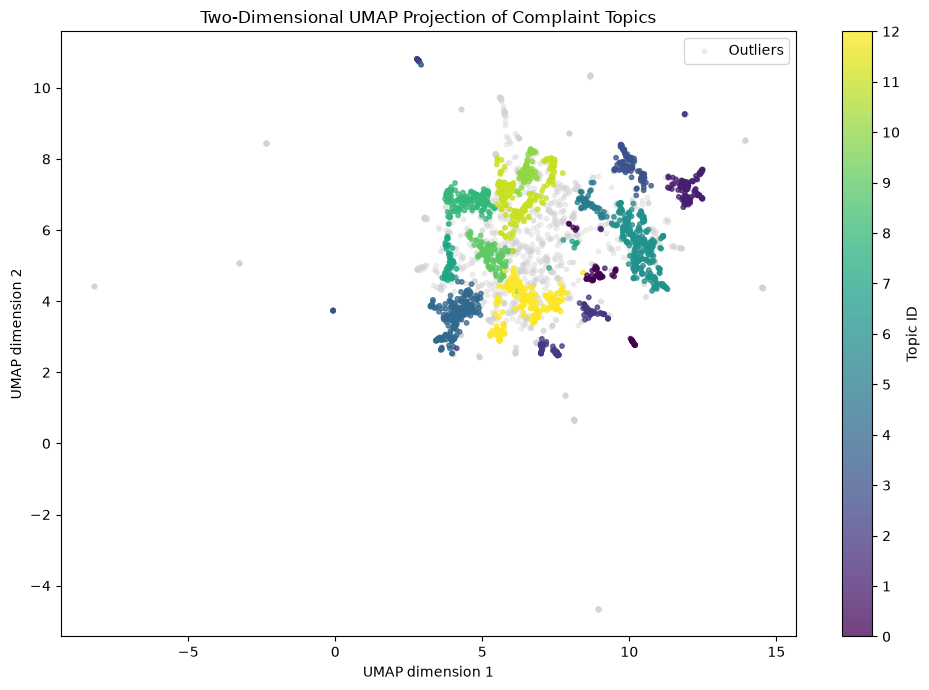

In [15]:
assigned_mask = final_labels != -1
outlier_mask = final_labels == -1

plt.figure(figsize=(10, 7))

plt.scatter(
    visual_umap[outlier_mask, 0],
    visual_umap[outlier_mask, 1],
    s=10,
    alpha=0.35,
    color="lightgray",
    label="Outliers",
)

scatter = plt.scatter(
    visual_umap[assigned_mask, 0],
    visual_umap[assigned_mask, 1],
    c=final_labels[assigned_mask],
    s=10,
    alpha=0.75,
    cmap="viridis",
)

plt.title("Two-Dimensional UMAP Projection of Complaint Topics")
plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")

colorbar = plt.colorbar(scatter)
colorbar.set_label("Topic ID")
colorbar.set_ticks(sorted(set(final_labels) - {-1}))

plt.legend()
plt.tight_layout()
plt.show()

### 8.2 UMAP Neighborhood Sensitivity

UMAP's `n_neighbors` parameter controls how much the reduced representation emphasizes local versus broader semantic structure.

To evaluate its effect, four values were compared while keeping the embeddings and HDBSCAN parameters fixed. The comparison considered:

- number of topics;
- outlier rate;
- size of the largest topic;
- balance across topics.

In [16]:
UMAP_NEIGHBOR_VALUES = [10, 15, 30, 50]

umap_sensitivity_results = {}
umap_summary_rows = []

for n_neighbors in UMAP_NEIGHBOR_VALUES:
    reduced = UMAP(
        n_neighbors=n_neighbors,
        n_components=5,
        min_dist=0.0,
        metric="cosine",
        random_state=42,
    ).fit_transform(embeddings)

    model = HDBSCAN(
        min_cluster_size=50,
        min_samples=20,
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True,
    )

    labels = model.fit_predict(reduced)

    assigned_labels = labels[labels != -1]
    topic_sizes = pd.Series(assigned_labels).value_counts()

    n_topics = len(topic_sizes)
    n_assigned = int((labels != -1).sum())
    n_outliers = int((labels == -1).sum())
    largest_topic_size = (
        int(topic_sizes.iloc[0])
        if not topic_sizes.empty
        else 0
    )

    umap_sensitivity_results[n_neighbors] = {
        "labels": labels,
        "umap_embeddings": reduced,
    }

    umap_summary_rows.append({
        "n_neighbors": n_neighbors,
        "topics": n_topics,
        "assigned": n_assigned,
        "outlier_rate_pct": (
            n_outliers / len(labels) * 100
        ),
        "largest_topic_pct": (
            largest_topic_size / len(labels) * 100
        ),
    })

umap_sensitivity_df = pd.DataFrame(umap_summary_rows)

display(
    umap_sensitivity_df.round(1)
)

,n_neighbors,topics,assigned,outlier_rate_pct,largest_topic_pct
0,10,13,1727,40.5,12.1
1,15,3,2770,4.5,87.8
2,30,10,1804,37.8,11.7
3,50,5,2387,17.7,57.6


### Interpretation

Changing the UMAP neighborhood size noticeably affected the resulting cluster structure.

The `n_neighbors=15` model collapsed most complaints into one dominant topic, while `n_neighbors=30` produced a more balanced structure but later showed instability across random seeds. The `n_neighbors=50` model also reduced the outlier rate, but it produced only five topics and placed 57.6% of complaints into one dominant cluster.

`n_neighbors=10` produced the clearest separation between complaint groups while avoiding excessive merging of topics. Based on these results, subsequent analyses used `n_neighbors=10`.

### 8.3 Stability Across Random Seeds

The neighborhood sensitivity results identified `n_neighbors=10` as the strongest candidate. Other settings were either overly coarse or unstable during exploratory testing.

Because UMAP uses stochastic initialization, the selected setting was tested across five random seeds to determine whether the topic structure depended on one particular run.

Adjusted Rand Index (ARI) was used to measure agreement between each pair of clustering results. Higher values indicate more similar complaint assignments across runs.

In [17]:
STABILITY_SEEDS = [11, 22, 33, 42, 55]

seed_results_n10 = {}

for seed in STABILITY_SEEDS:
    reduced = UMAP(
        n_neighbors=10,
        n_components=5,
        min_dist=0.0,
        metric="cosine",
        random_state=seed,
    ).fit_transform(embeddings)

    model = HDBSCAN(
        min_cluster_size=50,
        min_samples=20,
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True,
    )

    labels = model.fit_predict(reduced)

    seed_results_n10[seed] = {
        "labels": labels,
        "topics": len(set(labels) - {-1}),
        "assigned": int((labels != -1).sum()),
        "outliers": int((labels == -1).sum()),
    }

In [18]:
stability_rows = []

for seed_a, seed_b in combinations(STABILITY_SEEDS, 2):
    stability_rows.append({
        "seed_a": seed_a,
        "seed_b": seed_b,
        "ARI": adjusted_rand_score(
            seed_results_n10[seed_a]["labels"],
            seed_results_n10[seed_b]["labels"],
        ),
    })

stability_df = pd.DataFrame(stability_rows)

seed_summary = pd.DataFrame([
    {
        "seed": seed,
        "topics": result["topics"],
        "assigned": result["assigned"],
        "outlier_rate_pct": (
            result["outliers"]
            / len(df_credit)
            * 100
        ),
    }
    for seed, result in seed_results_n10.items()
])

display(stability_df.round(3))
display(seed_summary.round(1))

print(f"Mean ARI: {stability_df['ARI'].mean():.3f}")
print(f"Minimum ARI: {stability_df['ARI'].min():.3f}")
print(f"Maximum ARI: {stability_df['ARI'].max():.3f}")

,seed_a,seed_b,ARI
0,11,22,0.749
1,11,33,0.720
2,11,42,0.769
3,11,55,0.773
4,22,33,0.721
5,22,42,0.729
6,22,55,0.737
7,33,42,0.716
8,33,55,0.734
9,42,55,0.753


,seed,topics,assigned,outlier_rate_pct
0,11,12,1832,36.9
1,22,13,1838,36.7
2,33,12,1826,37.1
3,42,13,1727,40.5
4,55,13,1823,37.2


Mean ARI: 0.740
Minimum ARI: 0.716
Maximum ARI: 0.773


The `n_neighbors=10` configuration produced 12–13 topics across all five seeds. Pairwise ARI values ranged from 0.716 to 0.773, with a mean of 0.740.

This result indicates that the broad topic structure was reasonably consistent across repeated UMAP runs. Seed 22 was selected as the representative run because it produced 13 topics with one of the lowest outlier rates.

### 8.4 HDBSCAN Parameter Sensitivity

After selecting `n_neighbors=10`, several HDBSCAN configurations were compared.

The analysis varied:

- `min_cluster_size`: 50, 75, and 100;
- `min_samples`: 10, 20, and 30.

The goal was to determine whether a smaller number of topics could be achieved without creating unstable or overly broad clusters.

In [19]:
HDBSCAN_GRID = [
    {"min_cluster_size": 50, "min_samples": 10},
    {"min_cluster_size": 50, "min_samples": 20},
    {"min_cluster_size": 50, "min_samples": 30},
    {"min_cluster_size": 75, "min_samples": 10},
    {"min_cluster_size": 75, "min_samples": 20},
    {"min_cluster_size": 75, "min_samples": 30},
    {"min_cluster_size": 100, "min_samples": 10},
    {"min_cluster_size": 100, "min_samples": 20},
    {"min_cluster_size": 100, "min_samples": 30},
]

tuning_umap = UMAP(
    n_neighbors=10,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=22,
).fit_transform(embeddings)

hdbscan_tuning_results = {}
tuning_rows = []

for params in HDBSCAN_GRID:
    mcs = params["min_cluster_size"]
    ms = params["min_samples"]
    name = f"{mcs}/{ms}"

    model = HDBSCAN(
        min_cluster_size=mcs,
        min_samples=ms,
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True,
    )

    labels = model.fit_predict(tuning_umap)

    topic_sizes = (
        pd.Series(labels[labels != -1])
        .value_counts()
    )

    largest_topic_size = (
        int(topic_sizes.iloc[0])
        if not topic_sizes.empty
        else 0
    )

    hdbscan_tuning_results[name] = labels

    tuning_rows.append({
        "configuration": name,
        "topics": len(topic_sizes),
        "assigned": int((labels != -1).sum()),
        "outlier_rate_pct": (
            (labels == -1).mean() * 100
        ),
        "largest_topic_pct": (
            largest_topic_size / len(labels) * 100
        ),
    })

hdbscan_tuning_df = pd.DataFrame(tuning_rows)

display(
    hdbscan_tuning_df
    .sort_values(["topics", "outlier_rate_pct"])
    .round(1)
)

,configuration,topics,assigned,outlier_rate_pct,largest_topic_pct
8,100/30,5,1721,40.7,28.7
6,100/10,9,2011,30.7,14.6
7,100/20,9,1657,42.9,13.5
5,75/30,9,1500,48.3,12.2
3,75/10,11,2081,28.3,14.6
4,75/20,11,1818,37.4,13.5
2,50/30,12,1613,44.4,12.2
1,50/20,13,1838,36.7,10.4
0,50/10,14,2014,30.6,14.6


Some configurations produced attractive single-run results. For example, `100/10` produced nine topics and `75/10` produced eleven topics.

However, repeated runs across random seeds showed that these configurations were unstable. Depending on the seed, they collapsed into as few as two to five broad clusters. For this reason, they were rejected even though their initial topic counts appeared desirable.

The final model therefore retained min_cluster_size=50 and min_samples=20, which provided the best balance between topic detail, interpretability, and stability.

### 8.5 Final Model Configuration

The selected UMAP and HDBSCAN settings are summarized below.

In [20]:
final_model_table = pd.DataFrame({
    "Component": [
        "Embedding model",
        "Embedding dimensions",
        "UMAP neighbors",
        "UMAP dimensions",
        "UMAP metric",
        "UMAP random seed",
        "HDBSCAN minimum cluster size",
        "HDBSCAN minimum samples",
        "Topics",
        "Assigned complaints",
        "Outliers",
        "Outlier rate",
    ],
    "Selected value": [
        "all-mpnet-base-v2",
        embeddings.shape[1],
        FINAL_UMAP_NEIGHBORS,
        5,
        "cosine",
        FINAL_UMAP_SEED,
        FINAL_MIN_CLUSTER_SIZE,
        FINAL_MIN_SAMPLES,
        len(set(final_labels) - {-1}),
        int((final_labels != -1).sum()),
        int((final_labels == -1).sum()),
        f"{(final_labels == -1).mean() * 100:.1f}%",
    ],
})

display(final_model_table)

,Component,Selected value
0,Embedding model,all-mpnet-base-v2
1,Embedding dimensions,768
2,UMAP neighbors,10
3,UMAP dimensions,5
4,UMAP metric,cosine
5,UMAP random seed,22
6,HDBSCAN minimum cluster size,50
7,HDBSCAN minimum samples,20
8,Topics,13
9,Assigned complaints,1838


### Final Model Summary

The selected model identified 13 complaint topics from 2,902 credit-reporting complaints.

A total of 1,838 complaints (63.3%) were assigned to one of the discovered topics, while 1,064 complaints (36.7%) were labeled as outliers by HDBSCAN.

The next section interprets each topic using representative complaints, TF-IDF keywords, and CFPB Issue and Sub-issue labels.

## 9. Topic Interpretation

The selected model identified 13 topics among the 2,902 credit-reporting complaints.

Topic labels were assigned manually using several sources of evidence:

- topic-specific keywords after removing common and domain-wide terms;
- complaints closest to each topic centroid;
- the most common CFPB Issue and Sub-issue labels;
- topic size and share of the modeling dataset.

The topic names are intended to summarize the dominant theme in each cluster. They do not replace the original CFPB classifications.

In [21]:
df_final = df_credit.copy()
df_final["topic_id"] = final_labels

assert len(df_final) == len(df_credit)
assert len(final_labels) == len(df_credit)

print(f"Complaints analyzed: {len(df_final):,}")
print(f"Topics identified: {len(set(final_labels) - {-1})}")
print(f"Assigned complaints: {(final_labels != -1).sum():,}")
print(f"Outliers: {(final_labels == -1).sum():,}")

Complaints analyzed: 2,902
Topics identified: 13
Assigned complaints: 1,838
Outliers: 1,064


In [22]:
domain_stop_words = set(ENGLISH_STOP_WORDS).union({
    # Masking artifacts
    "masked_text",
    "masked_date",
    "masked_amount",
    "redacted",

    # Common credit-reporting terms
    "credit",
    "report",
    "reporting",
    "consumer",
    "complaint",
    "information",
    "account",
    "accounts",

    # Common legal language
    "fcra",
    "usc",
    "section",
    "act",
    "law",
    "rights",
    "fair",
    "states",
    "agency",

    # Numbers and formatting artifacts
    "00",
    "15",
    "1681",
    "year",
    "date",

    # Generic request language
    "request",
    "requested",
    "provide",
    "provided",
    "please",
    "writing",
})

In [23]:
# Fit TF-IDF separately within each topic to identify its most
# characteristic recurring terms. Scores are used only for ranking
# terms within that topic.

topic_keyword_rows = []

for topic_id in sorted(set(final_labels) - {-1}):
    topic_texts = df_final.loc[
        df_final["topic_id"] == topic_id,
        "cleaned_narrative",
    ].astype(str)

    vectorizer = TfidfVectorizer(
        stop_words=list(domain_stop_words),
        max_features=5_000,
        min_df=2,
        ngram_range=(1, 2),
    )

    matrix = vectorizer.fit_transform(topic_texts)
    mean_scores = np.asarray(matrix.mean(axis=0)).ravel()
    terms = np.array(vectorizer.get_feature_names_out())

    top_indices = mean_scores.argsort()[::-1][:12]

    topic_keyword_rows.append({
        "topic_id": topic_id,
        "size": len(topic_texts),
        "share_pct": (
            len(topic_texts) / len(df_final) * 100
        ),
        "top_terms": ", ".join(terms[top_indices]),
    })

topic_keywords = pd.DataFrame(topic_keyword_rows)

display(topic_keywords.round({"share_pct": 1}))

,topic_id,size,share_pct,top_terms
0,0,80,2.8,"privacy, violated, furnish, written, right, violation, 602, right privacy, instructions, written instructions, accordance, furnish written"
1,1,144,5.0,"inquiries, inquiry, unauthorized, hard, did, hard inquiries, fraudulent, dispute, purpose, removed, permissible, transunion"
2,2,112,3.9,"inaccurate, reported, inaccuracies, financial, errors, removal, file, incorrect, accuracy, documents, issue, investigation"
3,3,113,3.9,"identity, theft, identity theft, inquiries, hard inquiries, collections, hard, fraudulent, aforementioned, fraud, theft fraud, result"
4,4,227,7.8,"late, payment, payments, late payment, late payments, inaccurate, reported, dispute, days, time, paid, history"
5,5,50,1.7,"identity, identity theft, theft, experian, fraudulent, ftc, opened, dispute, documentation, ftc identity, 1681i, block"
6,6,303,10.4,"identity, theft, fraudulent, identity theft, opened, balance, removed, data, items, breach, 1681c, inquiries"
7,7,59,2.0,"payment, late, loan, company, payments, vehicle, balance, card, told, closed, paid, auto"
8,8,162,5.6,"debt, collection, validation, original, dispute, creditor, proof, documentation, fdcpa, reported, inaccurate, bureaus"
9,9,106,3.7,"charge, inaccurate, reported, balance, debt, charged, dispute, accurate, removed, investigation, accuracy, payment"


In [24]:
representative_rows = []

for topic_id in sorted(set(final_labels) - {-1}):
    topic_indices = np.where(final_labels == topic_id)[0]
    topic_embeddings = embeddings[topic_indices]

    centroid = topic_embeddings.mean(axis=0, keepdims=True)

    similarities = cosine_similarity(
        topic_embeddings,
        centroid,
    ).ravel()

    top_local_indices = similarities.argsort()[::-1][:3]

    for rank, local_idx in enumerate(top_local_indices, start=1):
        global_idx = topic_indices[local_idx]
        complaint = df_final.iloc[global_idx]

        representative_rows.append({
            "topic_id": topic_id,
            "rank": rank,
            "Complaint ID": complaint["Complaint ID"],
            "centroid_similarity": similarities[local_idx],
            "Issue": complaint["Issue"],
            "Sub-issue": complaint["Sub-issue"],
            "cleaned_narrative": complaint["cleaned_narrative"],
        })

representative_complaints = pd.DataFrame(
    representative_rows
)

In [25]:
representative_preview = (
    representative_complaints
    .loc[representative_complaints["rank"] == 1]
    [
        [
            "topic_id",
            "Complaint ID",
            "Issue",
            "Sub-issue",
            "centroid_similarity",
            "cleaned_narrative",
        ]
    ]
)

display(representative_preview)

,topic_id,Complaint ID,Issue,Sub-issue,centroid_similarity,cleaned_narrative
0,0,13879490,Improper use of your report,Reporting company used your report improperly,0.948104,"am writing to you regarding a violation of my privacy and confidentiality rights, protected under the Fair Credit Reporting Act ( 15 USC 1681b ( 2 ) ). Pursuant to 18 USC 8, I have identified the ..."
3,1,13517204,Incorrect information on your report,Account information incorrect,0.941390,"Subject : Request for Removal of Unauthorized Hard Inquiries from My Credit Report To Whom It May Concern, My name is [MASKED_TEXT] [MASKED_TEXT] [MASKED_TEXT] [MASKED_TEXT], a resident of the [MA..."
6,2,12435934,Improper use of your report,Reporting company used your report improperly,0.906911,"I am reaching out to express serious concerns about errors I have discovered in my credit report. Upon reviewing it, I identified multiple inaccuracies, including incorrect account listings, unaut..."
9,3,14871578,Incorrect information on your report,Information belongs to someone else,0.980395,"[MASKED_TEXT] [MASKED_TEXT], [MASKED_TEXT], [MASKED_DATE] This CFPB complaint has been filed to request pursuant to FCRA 605B ( 15 U.S.C. 1681c-2 ) that you, the TransUnion credit reporting agency..."
12,4,13876798,Incorrect information on your report,Account information incorrect,0.943180,"To Whom It May Concern, This letter is a formal dispute of the inaccurate and damaging late payment entries reported on my credit file by [MASKED_TEXT] [MASKED_TEXT] [MASKED_TEXT] [MASKED_TEXT] [M..."
15,5,16113942,Incorrect information on your report,Information belongs to someone else,0.956787,I am authorizing the submission of dispute letters and the filing of this complaint through the Consumer Financial Protection Bureaus online system on my behalf. This authorization serves as confi...
18,6,11418892,Incorrect information on your report,Account information incorrect,0.947710,I am writing to formally dispute and demand the immediate removal of the following fraudulent accounts and inquiries from my credit report due to identity theft. These accounts were opened without...
21,7,14488960,Problem with a company's investigation into an existing problem,Problem with personal statement of dispute,0.891323,"[MASKED_TEXT] [MASKED_TEXT] [MASKED_TEXT] and [MASKED_TEXT] reported 6 late payments to creditors experian, [MASKED_TEXT] and [MASKED_TEXT] [MASKED_TEXT] for money that was paid from my bank accou..."
24,8,13686895,Incorrect information on your report,Old information reappears or never goes away,0.938163,"Dear CFPB, I am submitting this formal complaint regarding a collection account listed by [MASKED_TEXT] [MASKED_TEXT] [MASKED_TEXT] on my Experian and Equifax credit reports. Despite three separat..."
27,9,16959287,Incorrect information on your report,Information belongs to someone else,0.946246,I am submitting a complaint to follow up on my previous disputes regarding the account [MASKED_TEXT] [MASKED_TEXT] [MASKED_TEXT] which is currently reported with a balance of {$0.00} and classifie...


In [26]:
def top_value_summary(series, top_n=3):
    counts = series.fillna("Missing").value_counts()
    total = counts.sum()

    return "; ".join(
        f"{label} ({count / total * 100:.1f}%)"
        for label, count in counts.head(top_n).items()
    )

In [27]:
topic_metadata_rows = []

for topic_id in sorted(set(final_labels) - {-1}):
    topic_df = df_final.loc[
        df_final["topic_id"] == topic_id
    ]

    topic_metadata_rows.append({
        "topic_id": topic_id,
        "size": len(topic_df),
        "share_pct": len(topic_df) / len(df_final) * 100,
        "top_issues": top_value_summary(topic_df["Issue"]),
        "top_sub_issues": top_value_summary(
            topic_df["Sub-issue"]
        ),
    })

topic_metadata = pd.DataFrame(topic_metadata_rows)

In [28]:
topic_names = {
    0: "FCRA Privacy and Permissible-Purpose Violations",
    1: "Unauthorized Hard Credit Inquiries",
    2: "General Credit-Report Inaccuracies",
    3: "FCRA 605B Identity-Theft Blocking Requests",
    4: "Late-Payment Reporting Errors",
    5: "Failure to Remove Identity-Theft Accounts",
    6: "Identity Theft and Fraudulent Accounts",
    7: "Auto Loan and Payment-History Disputes",
    8: "Debt Collection and Debt Validation",
    9: "Charge-Off and Account-Status Disputes",
    10: "Equifax Investigation Failures",
    11: "Multi-Bureau Reinvestigation Failures",
    12: "Account and Personal-Information Inaccuracies",
}

In [29]:
topic_summary = (
    topic_metadata
    .merge(
        topic_keywords[
            ["topic_id", "top_terms"]
        ],
        on="topic_id",
        how="left",
    )
)

topic_summary["topic_name"] = (
    topic_summary["topic_id"].map(topic_names)
)

topic_summary = topic_summary[
    [
        "topic_id",
        "topic_name",
        "size",
        "share_pct",
        "top_terms",
        "top_issues",
        "top_sub_issues",
    ]
]

display(topic_summary.round({"share_pct": 1}))

,topic_id,topic_name,size,share_pct,top_terms,top_issues,top_sub_issues
0,0,FCRA Privacy and Permissible-Purpose Violations,80,2.8,"privacy, violated, furnish, written, right, violation, 602, right privacy, instructions, written instructions, accordance, furnish written",Improper use of your report (60.0%); Incorrect information on your report (31.2%); Problem with a company's investigation into an existing problem (8.8%),Reporting company used your report improperly (56.2%); Information belongs to someone else (21.2%); Their investigation did not fix an error on your report (6.2%)
1,1,Unauthorized Hard Credit Inquiries,144,5.0,"inquiries, inquiry, unauthorized, hard, did, hard inquiries, fraudulent, dispute, purpose, removed, permissible, transunion",Improper use of your report (79.9%); Incorrect information on your report (13.2%); Problem with a company's investigation into an existing problem (5.6%),Credit inquiries on your report that you don't recognize (66.7%); Reporting company used your report improperly (12.5%); Information belongs to someone else (10.4%)
2,2,General Credit-Report Inaccuracies,112,3.9,"inaccurate, reported, inaccuracies, financial, errors, removal, file, incorrect, accuracy, documents, issue, investigation",Incorrect information on your report (74.1%); Problem with a company's investigation into an existing problem (15.2%); Improper use of your report (9.8%),Information belongs to someone else (35.7%); Account information incorrect (28.6%); Their investigation did not fix an error on your report (14.3%)
3,3,FCRA 605B Identity-Theft Blocking Requests,113,3.9,"identity, theft, identity theft, inquiries, hard inquiries, collections, hard, fraudulent, aforementioned, fraud, theft fraud, result",Incorrect information on your report (63.7%); Improper use of your report (26.5%); Problem with a company's investigation into an existing problem (9.7%),Information belongs to someone else (56.6%); Reporting company used your report improperly (21.2%); Account information incorrect (6.2%)
4,4,Late-Payment Reporting Errors,227,7.8,"late, payment, payments, late payment, late payments, inaccurate, reported, dispute, days, time, paid, history",Incorrect information on your report (52.9%); Improper use of your report (28.2%); Problem with a company's investigation into an existing problem (18.9%),Reporting company used your report improperly (27.8%); Account status incorrect (24.7%); Account information incorrect (21.6%)
5,5,Failure to Remove Identity-Theft Accounts,50,1.7,"identity, identity theft, theft, experian, fraudulent, ftc, opened, dispute, documentation, ftc identity, 1681i, block",Incorrect information on your report (58.0%); Problem with a company's investigation into an existing problem (38.0%); Improper use of your report (4.0%),Information belongs to someone else (54.0%); Their investigation did not fix an error on your report (28.0%); Investigation took more than 30 days (6.0%)
6,6,Identity Theft and Fraudulent Accounts,303,10.4,"identity, theft, fraudulent, identity theft, opened, balance, removed, data, items, breach, 1681c, inquiries",Incorrect information on your report (60.7%); Improper use of your report (22.1%); Problem with a company's investigation into an existing problem (14.5%),Information belongs to someone else (44.6%); Reporting company used your report improperly (17.2%); Account information incorrect (11.2%)
7,7,Auto Loan and Payment-History Disputes,59,2.0,"payment, late, loan, company, payments, vehicle, balance, card, told, closed, paid, auto",Incorrect information on your report (69.5%); Problem with a company's investigation into an existing problem (18.6%); Improper use of your report (8.5%),Account information incorrect (33.9%); Account status incorrect (28.8%); Reporting company used your report improperly (8.5%)
8,8,Debt Collection and Debt Validation,162,5.6,"debt, collection, validation, original, dispute, creditor, proof, documentation, fdcpa, reported, inaccurate, bureaus"

### Summary of the 13 Topics

**Topic 0 — FCRA Privacy and Permissible-Purpose Violations**  
Complaints alleging that consumer reports were accessed, furnished, or used without authorization or a valid permissible purpose. These narratives emphasize privacy rights and the legal conditions under which a report may be accessed.

**Topic 1 — Unauthorized Hard Credit Inquiries**  
Complaints about hard inquiries that consumers did not recognize or authorize. Consumers commonly request removal and state that the company lacked consent or a permissible purpose.

**Topic 2 — General Credit-Report Inaccuracies**  
Broad disputes involving incorrect listings, unauthorized accounts, incomplete information, and unresolved reporting errors that do not consistently fall into a more specific theme.

**Topic 3 — FCRA 605B Identity-Theft Blocking Requests**  
Formal requests to block or delete fraudulent information under FCRA Section 605B. Many complaints use similar legal wording and focus on a specific identity-theft remedy.

**Topic 4 — Late-Payment Reporting Errors**  
Disputes involving incorrect late-payment marks, delinquency reporting, payment-processing errors, autopay problems, or inaccurate payment histories.

**Topic 5 — Failure to Remove Identity-Theft Accounts**  
Complaints in which consumers state that identity-theft evidence or FTC documentation was submitted but fraudulent accounts were not removed.

**Topic 6 — Identity Theft and Fraudulent Accounts**  
Broader identity-theft narratives involving data breaches, unauthorized accounts, fraudulent balances, unknown inquiries, and requests to remove fraudulent information.

**Topic 7 — Auto Loan and Payment-History Disputes**  
Account-specific disputes involving vehicle loans, lender instructions, autopay, account balances, and inaccurate delinquency reporting.

**Topic 8 — Debt Collection and Debt Validation**  
Complaints about collection accounts, requests for validation, original-creditor documentation, proof of debt, and alleged FDCPA violations.

**Topic 9 — Charge-Off and Account-Status Disputes**  
Disputes involving charge-offs, balances, closed or paid accounts, account status, and requests to remove unverifiable information.

**Topic 10 — Equifax Investigation Failures**  
Complaints alleging that Equifax failed to conduct a reasonable investigation or correct disputed information.

**Topic 11 — Multi-Bureau Reinvestigation Failures**  
Complaints involving Experian, TransUnion, Equifax, or multiple bureaus failing to investigate, correct, or consistently report disputed information.

**Topic 12 — Account and Personal-Information Inaccuracies**  
Disputes about specific report fields, including balances, dates opened, addresses, account numbers, personal information, and outdated data.

## 10. Topic Similarity and Broader Themes

Several topics address related problems, especially identity theft, inaccurate account reporting, and failed dispute investigations.

To evaluate their relationships, cosine similarity was calculated between topic centroids in the original sentence-embedding space. High similarity indicates that two topics occupy nearby semantic regions, but it does not automatically mean that they should be merged.

In [30]:
assigned_topic_ids = sorted(set(final_labels) - {-1})

topic_centroids = {}
topic_sizes = {}

for topic_id in assigned_topic_ids:
    topic_mask = final_labels == topic_id
    topic_embeddings = embeddings[topic_mask]

    topic_centroids[topic_id] = topic_embeddings.mean(axis=0)
    topic_sizes[topic_id] = int(topic_mask.sum())

centroid_matrix = np.vstack([
    topic_centroids[topic_id]
    for topic_id in assigned_topic_ids
])

topic_similarity_matrix = cosine_similarity(
    centroid_matrix
)

In [31]:
topic_pair_rows = []

for i, topic_a in enumerate(assigned_topic_ids):
    for j in range(i + 1, len(assigned_topic_ids)):
        topic_b = assigned_topic_ids[j]

        topic_pair_rows.append({
            "topic_a": topic_a,
            "topic_a_name": topic_names[topic_a],
            "topic_b": topic_b,
            "topic_b_name": topic_names[topic_b],
            "similarity": topic_similarity_matrix[i, j],
        })

topic_pair_similarity = (
    pd.DataFrame(topic_pair_rows)
    .sort_values("similarity", ascending=False)
    .reset_index(drop=True)
)

display(topic_pair_similarity.head(12).round(3))

,topic_a,topic_a_name,topic_b,topic_b_name,similarity
0,10,Equifax Investigation Failures,11,Multi-Bureau Reinvestigation Failures,0.952
1,5,Failure to Remove Identity-Theft Accounts,11,Multi-Bureau Reinvestigation Failures,0.933
2,9,Charge-Off and Account-Status Disputes,12,Account and Personal-Information Inaccuracies,0.931
3,11,Multi-Bureau Reinvestigation Failures,12,Account and Personal-Information Inaccuracies,0.930
4,3,FCRA 605B Identity-Theft Blocking Requests,5,Failure to Remove Identity-Theft Accounts,0.929
5,5,Failure to Remove Identity-Theft Accounts,6,Identity Theft and Fraudulent Accounts,0.927
6,3,FCRA 605B Identity-Theft Blocking Requests,6,Identity Theft and Fraudulent Accounts,0.924
7,8,Debt Collection and Debt Validation,9,Charge-Off and Account-Status Disputes,0.915
8,9,Charge-Off and Account-Status Disputes,11,Multi-Bureau Reinvestigation Failures,0.912
9,4,Late-Payment Reporting Errors,12,Account and Personal-Information Inaccuracies,0.906


In [32]:
topic_families = pd.DataFrame([
    {
        "thematic_family": "Privacy and inquiry issues",
        "topic_ids": "0, 1",
        "included_topics": (
            "FCRA privacy and permissible-purpose violations; "
            "unauthorized hard inquiries"
        ),
    },
    {
        "thematic_family": "General report and account inaccuracies",
        "topic_ids": "2, 12",
        "included_topics": (
            "General report inaccuracies; account and "
            "personal-information inaccuracies"
        ),
    },
    {
        "thematic_family": "Identity theft and fraudulent information",
        "topic_ids": "3, 5, 6",
        "included_topics": (
            "605B blocking requests; failure to remove "
            "fraudulent accounts; broader identity theft"
        ),
    },
    {
        "thematic_family": "Payment-history issues",
        "topic_ids": "4, 7",
        "included_topics": (
            "Late-payment reporting; auto-loan and "
            "payment-history disputes"
        ),
    },
    {
        "thematic_family": "Collections and account status",
        "topic_ids": "8, 9",
        "included_topics": (
            "Debt collection and validation; charge-off "
            "and account-status disputes"
        ),
    },
    {
        "thematic_family": "Investigation failures",
        "topic_ids": "10, 11",
        "included_topics": (
            "Equifax investigation failures; "
            "multi-bureau reinvestigation failures"
        ),
    },
])

display(topic_families)

,thematic_family,topic_ids,included_topics
0,Privacy and inquiry issues,"0, 1",FCRA privacy and permissible-purpose violations; unauthorized hard inquiries
1,General report and account inaccuracies,"2, 12",General report inaccuracies; account and personal-information inaccuracies
2,Identity theft and fraudulent information,"3, 5, 6",605B blocking requests; failure to remove fraudulent accounts; broader identity theft
3,Payment-history issues,"4, 7",Late-payment reporting; auto-loan and payment-history disputes
4,Collections and account status,"8, 9",Debt collection and validation; charge-off and account-status disputes
5,Investigation failures,"10, 11",Equifax investigation failures; multi-bureau reinvestigation failures


The 13 HDBSCAN topics were retained as separate model outputs. The broader families above are used only to summarize closely related complaint patterns.

The strongest centroid similarity occurred between Topics 10 and 11, which both concern failed investigations. Topics 3, 5, and 6 also formed a closely related identity-theft group. Other overlap appeared between charge-off disputes, account-status errors, and broader account-information inaccuracies.

These relationships are expected because all complaints come from the same credit-reporting domain and often share legal and dispute language. The clusters were not manually merged because the representative narratives and CFPB labels still showed meaningful differences in issue type, bureau focus, or stage of the dispute process.

## 11. Outlier Analysis

HDBSCAN labels complaints as outliers when they do not belong to a sufficiently dense cluster. These complaints are not necessarily errors or low-quality narratives. Instead, they may represent uncommon issues, mixed complaint themes, or complaints located near the boundary between two topics.

This section compares assigned complaints and outliers using narrative length, CFPB categories, and similarity to the nearest topic centroid.

In [33]:
assigned_df = df_final.loc[
    df_final["topic_id"] != -1
].copy()

outlier_df = df_final.loc[
    df_final["topic_id"] == -1
].copy()

outlier_summary = pd.Series({
    "Total complaints": len(df_final),
    "Assigned complaints": len(assigned_df),
    "Outliers": len(outlier_df),
    "Outlier rate (%)": (
        len(outlier_df) / len(df_final) * 100
    ),
})

display(outlier_summary.to_frame("value").round(1))

,value
Total complaints,2902.0
Assigned complaints,1838.0
Outliers,1064.0
Outlier rate (%),36.7


In [34]:
length_summary = pd.DataFrame({
    "Group": ["Assigned", "Outliers"],
    "Mean words": [
        assigned_df["word_count"].mean(),
        outlier_df["word_count"].mean(),
    ],
    "Median words": [
        assigned_df["word_count"].median(),
        outlier_df["word_count"].median(),
    ],
    "Minimum words": [
        assigned_df["word_count"].min(),
        outlier_df["word_count"].min(),
    ],
    "Maximum words": [
        assigned_df["word_count"].max(),
        outlier_df["word_count"].max(),
    ],
})

display(length_summary.round(1))

,Group,Mean words,Median words,Minimum words,Maximum words
0,Assigned,187.2,158.5,50,500
1,Outliers,182.6,148.0,50,498


In [35]:
assigned_issue = (
    assigned_df["Issue"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("Assigned (%)")
)

outlier_issue = (
    outlier_df["Issue"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("Outliers (%)")
)

issue_comparison = pd.concat(
    [assigned_issue, outlier_issue],
    axis=1,
).fillna(0)

issue_comparison["Difference (percentage points)"] = (
    issue_comparison["Outliers (%)"]
    - issue_comparison["Assigned (%)"]
)

display(
    issue_comparison
    .sort_values(
        "Difference (percentage points)",
        ascending=False,
    )
    .round(1)
)

,Assigned (%),Outliers (%),Difference (percentage points)
Issue,,,
Problem with a company's investigation into an existing problem,22.3,26.2,3.9
Unable to get your credit report or credit score,0.2,1.7,1.5
Problem with fraud alerts or security freezes,0.4,1.2,0.8
Credit monitoring or identity theft protection services,0.5,0.8,0.4
Problem with a company's investigation into an existing issue,0.1,0.1,0.0
Identity theft protection or other monitoring services,0.1,0.0,-0.1
Incorrect information on your report,51.1,49.1,-2.1
Improper use of your report,25.4,20.9,-4.5


In [36]:
assigned_sub_issue = (
    assigned_df["Sub-issue"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("Assigned (%)")
)

outlier_sub_issue = (
    outlier_df["Sub-issue"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("Outliers (%)")
)

sub_issue_comparison = pd.concat(
    [assigned_sub_issue, outlier_sub_issue],
    axis=1,
).fillna(0)

sub_issue_comparison[
    "Difference (percentage points)"
] = (
    sub_issue_comparison["Outliers (%)"]
    - sub_issue_comparison["Assigned (%)"]
)

display(
    sub_issue_comparison
    .sort_values(
        "Difference (percentage points)",
        ascending=False,
    )
    .head(10)
    .round(1)
)

,Assigned (%),Outliers (%),Difference (percentage points)
Sub-issue,,,
Public record information inaccurate,0.3,2.4,2.1
Their investigation did not fix an error on your report,17.3,19.1,1.9
Investigation took more than 30 days,2.4,3.9,1.5
Other problem getting your report or credit score,0.2,1.3,1.2
Old information reappears or never goes away,0.9,1.6,0.7
Account information incorrect,14.0,14.7,0.7
Was not notified of investigation status or results,1.0,1.6,0.6
Problem getting your free annual credit report,0.0,0.4,0.4
Information is missing that should be on the report,0.3,0.7,0.3


### Initial Outlier Profile

Outlier complaints were not substantially shorter than assigned complaints. Their median narrative length was 148 words, compared with 158.5 words for assigned complaints. This suggests that HDBSCAN did not primarily classify complaints as outliers because they lacked detail.

Outliers were somewhat more common among complaints involving failed or delayed investigations, inaccurate public records, fraud alerts, security freezes, and difficulty obtaining a credit report. These complaint types appear to be more varied or less common than the recurring themes captured by the identified topics.

In [37]:
topic_ids = sorted(set(final_labels) - {-1})

centroid_matrix = np.vstack([
    topic_centroids[topic_id]
    for topic_id in topic_ids
])

outlier_positions = np.where(final_labels == -1)[0]
outlier_embeddings = embeddings[outlier_positions]

outlier_topic_similarities = cosine_similarity(
    outlier_embeddings,
    centroid_matrix,
)

nearest_topic_columns = (
    outlier_topic_similarities.argmax(axis=1)
)

nearest_topic_similarities = (
    outlier_topic_similarities.max(axis=1)
)

outlier_similarity_df = (
    df_final.iloc[outlier_positions]
    .copy()
    .reset_index(drop=True)
)

outlier_similarity_df["nearest_topic_id"] = [
    topic_ids[index]
    for index in nearest_topic_columns
]

outlier_similarity_df["nearest_topic_name"] = (
    outlier_similarity_df["nearest_topic_id"]
    .map(topic_names)
)

outlier_similarity_df[
    "nearest_topic_similarity"
] = nearest_topic_similarities

In [38]:
similarity_summary = (
    outlier_similarity_df[
        "nearest_topic_similarity"
    ]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)

display(
    similarity_summary
    .to_frame("Similarity")
    .round(3)
)

,Similarity
count,1064.000
mean,0.800
std,0.088
min,0.320
10%,0.688
25%,0.751
50%,0.814
75%,0.866
90%,0.897
95%,0.910


In [39]:
nearest_topic_distribution = (
    outlier_similarity_df[
        ["nearest_topic_id", "nearest_topic_name"]
    ]
    .value_counts()
    .rename("Outliers")
    .reset_index()
)

nearest_topic_distribution["Share (%)"] = (
    nearest_topic_distribution["Outliers"]
    / len(outlier_similarity_df)
    * 100
)

display(
    nearest_topic_distribution
    .head(8)
    .round({"Share (%)": 1})
)

,nearest_topic_id,nearest_topic_name,Outliers,Share (%)
0,11,Multi-Bureau Reinvestigation Failures,244,22.9
1,12,Account and Personal-Information Inaccuracies,186,17.5
2,6,Identity Theft and Fraudulent Accounts,103,9.7
3,9,Charge-Off and Account-Status Disputes,87,8.2
4,2,General Credit-Report Inaccuracies,83,7.8
5,7,Auto Loan and Payment-History Disputes,71,6.7
6,8,Debt Collection and Debt Validation,60,5.6
7,10,Equifax Investigation Failures,55,5.2


### Semantic Proximity of Outliers

The median similarity between an outlier and its nearest topic centroid was 0.814. More than half of the outliers had a similarity of at least 0.80, while 34.0% reached at least 0.85.

This indicates that many outliers are semantically similar to existing topics even though they were not assigned by the density-based clustering algorithm. Instead, they may be borderline cases located near topic boundaries. However, only 8.7% exceeded a similarity of 0.90, so nearest-centroid similarity alone was not considered strong enough to justify automatic reassignment.

Outliers were most often closest to broad themes involving multi-bureau investigation failures, account and personal-information inaccuracies, and identity theft. These topics likely have wider or overlapping semantic boundaries.

In [40]:
closest_outliers = (
    outlier_similarity_df
    .nlargest(
        5,
        "nearest_topic_similarity",
    )
)

most_isolated_outliers = (
    outlier_similarity_df
    .nsmallest(
        5,
        "nearest_topic_similarity",
    )
)

In [41]:
display_columns = [
    "Complaint ID",
    "Issue",
    "Sub-issue",
    "nearest_topic_name",
    "nearest_topic_similarity",
    "cleaned_narrative",
]

print("Borderline outliers closest to an existing topic")
display(closest_outliers[display_columns])

print("Most isolated outliers")
display(most_isolated_outliers[display_columns])

Borderline outliers closest to an existing topic


,Complaint ID,Issue,Sub-issue,nearest_topic_name,nearest_topic_similarity,cleaned_narrative
837,15524554,Incorrect information on your report,Account status incorrect,Multi-Bureau Reinvestigation Failures,0.952227,"Dear CFPB, I am filing a formal complaint against Experian, Equifax, or TransUnion regarding their handling of my [MASKED_TEXT] [MASKED_TEXT] credit dispute. I submitted a dispute regarding inaccu..."
271,12436467,Problem with a company's investigation into an existing problem,Their investigation did not fix an error on your report,Multi-Bureau Reinvestigation Failures,0.938178,"[MASKED_TEXT] has failed to fulfill its legal obligation under the Fair Credit Reporting Act ( FCRA ) to conduct a reasonable reinvestigation of disputed information on my credit report, leaving i..."
102,11717259,Problem with a company's investigation into an existing problem,Their investigation did not fix an error on your report,Multi-Bureau Reinvestigation Failures,0.936002,"[MASKED_TEXT] has a failed to fulfill its legal obligation under the Fair Credit Reporting Act ( FCRA ) to conduct a reasonable reinvestigation of dispute information on my credit report, leaving ..."
405,13066892,Incorrect information on your report,Account information incorrect,Account and Personal-Information Inaccuracies,0.935331,"[MASKED_TEXT] [MASKED_TEXT] [MASKED_TEXT] [MASKED_TEXT] [MASKED_TEXT] [MASKED_TEXT] [MASKED_TEXT] [MASKED_TEXT] [MASKED_TEXT], Louisiana, [MASKED_TEXT] [MASKED_TEXT] Date : [MASKED_TEXT]/[MASKED_T..."
262,12402166,Problem with a company's investigation into an existing problem,Their investigation did not fix an error on your report,Multi-Bureau Reinvestigation Failures,0.932681,[MASKED_TEXT] has failed to fulfill legal obligation under the Fair Credit Reporting Act ( FCRA ) to conduct a reasonable reinvestigation of disputed information on my credit report leaving inaccu...


Most isolated outliers


,Complaint ID,Issue,Sub-issue,nearest_topic_name,nearest_topic_similarity,cleaned_narrative
598,14147264,Unable to get your credit report or credit score,Other problem getting your report or credit score,Auto Loan and Payment-History Disputes,0.320142,All of my existing passwords to log into my Experian account have stopped working. I tried every single way to get back into my account to no avail. Then I decided to create a new password and whe...
1045,18231931,Incorrect information on your report,Account status incorrect,Auto Loan and Payment-History Disputes,0.398124,[MASKED_TEXT] Bank : [MASKED_TEXT] / : confirmation number [MASKED_TEXT] : [MASKED_TEXT] [MASKED_TEXT] [MASKED_TEXT] offer is valid for 30 days from the date of this email. [MASKED_TEXT] Bank Sett...
248,12336629,Improper use of your report,Reporting company used your report improperly,Equifax Investigation Failures,0.425866,15 U.S. Code 1681o - Civil liability for negligent noncompliance U.S. Code Notes [MASKED_TEXT]rev | next ( a ) In general Any person who is negligent in failing to comply with any requirement impo...
950,16814464,Incorrect information on your report,Information belongs to someone else,Late-Payment Reporting Errors,0.471009,"Due to a period of incarceration, I was unable to make timely payments on my credit card. It was a difficult time in my life, but Ive taken steps since then to rebuild and make things right. Im co..."
239,12302398,Incorrect information on your report,Account information incorrect,Debt Collection and Debt Validation,0.490988,I sent a letter Exeter Finance requesting 1099C Letter which they issued to me. Account is currently written off and they sold the account to another company called [MASKED_TEXT] [MASKED_TEXT]. I ...


### Review of Outlier Extremes

The outliers closest to existing topic centroids generally resembled borderline members of broad themes involving investigation failures and account inaccuracies.

In contrast, the most isolated complaints often described less common issues, such as account-access problems, security freezes, public-record disputes, bankruptcy reporting, or highly specific personal circumstances.

These examples illustrate two types of outliers: some complaints lie near existing topic boundaries, while others represent issues that did not occur frequently enough to form dense clusters.

### Outlier Treatment

The original HDBSCAN outlier labels were retained.

Although many outliers were semantically close to an existing topic, nearest-centroid assignment would force every complaint into a cluster even when the density-based model did not find sufficient evidence for membership. Retaining the outlier labels therefore preserves the behavior of HDBSCAN and avoids post hoc reassignment based only on semantic similarity.

The relatively high outlier rate reflects the conservative nature of HDBSCAN as well as the diversity of consumer complaints. Many complaints lie near the boundaries between topics or describe uncommon situations that do not occur frequently enough to form dense clusters. Retaining these records as outliers preserves the original behavior of the clustering algorithm without forcing uncertain assignments.

## 12. Additional Sensitivity Checks

### 12.1 UMAP Distance Metric

The selected model uses cosine distance in UMAP. To test whether the distance metric affects the cluster structure, cosine and Euclidean distance were compared while keeping the embeddings, random seed, dimensionality, and HDBSCAN parameters unchanged.

In [42]:
UMAP_METRICS = ["cosine", "euclidean"]

metric_results = {}
metric_summary_rows = []

for metric_name in UMAP_METRICS:
    
    reduced = UMAP(
        n_neighbors=FINAL_UMAP_NEIGHBORS,
        n_components=5,
        min_dist=0.0,
        metric=metric_name,
        random_state=FINAL_UMAP_SEED,
    ).fit_transform(embeddings)
    
    model = HDBSCAN(
        min_cluster_size=50,
        min_samples=20,
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True,
    )

    labels = model.fit_predict(reduced)

    topic_sizes = (
        pd.Series(labels[labels != -1])
        .value_counts()
    )

    largest_topic_size = (
        int(topic_sizes.iloc[0])
        if not topic_sizes.empty
        else 0
    )

    metric_results[metric_name] = labels

    metric_summary_rows.append({
        "UMAP metric": metric_name,
        "Topics": len(topic_sizes),
        "Outlier rate (%)": (
            (labels == -1).mean() * 100
        ),
        "Largest topic (%)": (
            largest_topic_size / len(labels) * 100
        ),
    })

metric_summary = pd.DataFrame(metric_summary_rows)

display(metric_summary.round(1))

metric_ari = adjusted_rand_score(
    metric_results["cosine"],
    metric_results["euclidean"],
)

print(
    f"ARI between cosine and Euclidean UMAP: "
    f"{metric_ari:.3f}"
)

,UMAP metric,Topics,Outlier rate (%),Largest topic (%)
0,cosine,13,36.7,10.4
1,euclidean,5,14.0,72.1


ARI between cosine and Euclidean UMAP: 0.058


Euclidean distance produced five topics, but 72.1% of all complaints were placed into one dominant cluster. Agreement with the cosine model was also very low (ARI = 0.058).

Cosine distance was therefore retained because it produced a more balanced and interpretable topic structure.

### 12.2 Legal-Boilerplate Removal

Because many complaints contained repeated legal language, a conservative preprocessing experiment removed common FCRA references and formulaic legal phrases before generating new sentence embeddings.

The transformation changed 2,213 of the 2,902 narratives while removing an average of only 2.6% of their characters. However, the resulting model collapsed into two topics, with 91.3% of complaints assigned to one cluster. Agreement with the selected model was nearly zero (ARI = 0.004).

Legal-boilerplate removal was therefore rejected. In this dataset, legal framing appears to contain information that helps distinguish complaint patterns rather than functioning only as irrelevant text.

### Sensitivity Summary

The additional sensitivity checks confirmed that the final topic structure depended on preserving the original semantic representation of the complaint narratives.

Cosine distance produced a more balanced and interpretable clustering structure than Euclidean distance. Removing standardized legal boilerplate also reduced topic separation and caused most complaints to collapse into a small number of broad clusters.

Based on these results, the original cleaned narratives and cosine-based UMAP representation were retained for the final model.

## 13. Limitations

This study has several limitations.

- Only one CFPB product category was analyzed.
- Topic interpretation required manual review.
- HDBSCAN leaves some complaints unassigned by design.
- Different embedding models may produce different topic structures.

Future work could compare additional embedding models, clustering algorithms, or incorporate BERTopic to automate topic labeling.

# 14. Conclusions

This study applied sentence-transformer embeddings, UMAP, and HDBSCAN to CFPB credit-reporting complaint narratives to identify recurring complaint themes.

The final model identified 13 interpretable topics covering privacy concerns, unauthorized inquiries, identity theft, payment reporting, debt collection, account inaccuracies, and bureau investigation failures. Approximately 63% of complaints were assigned to a stable topic, while 37% remained outliers.

Several sensitivity analyses were performed, including comparisons of UMAP neighborhood size, random seeds, HDBSCAN parameters, distance metrics, and legal-boilerplate removal. These experiments showed that the selected configuration produced the best balance between stability and topic interpretability.

Overall, the discovered topics complement the CFPB's existing Issue and Sub-issue labels by identifying recurring semantic patterns across complaint narratives.